In [1]:
import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import scanpy as sc
import sklearn
import numpy as np
import pandas as pd
import statsmodels as stat
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import gseapy as gp

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
raw_counts_df = pd.read_csv("/Users/alexchen/Desktop/Personal_Projects/JMML_Project/Data/GSE147523/GSE147523_raw_counts.tsv.gz", sep="\t", index_col=0)
annotation_df = pd.read_csv("/Users/alexchen/Desktop/Personal_Projects/JMML_Project/Data/GSE147523/GSE147523_HumanAnnotate.tsv.gz", sep="\t")

/var/folders/32/q9wbsvsd5bjdyq65l_r635n80000gn/T/ipykernel_23273/1332899599.py:2: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  annotation_df = pd.read_csv("/Users/alexchen/Desktop/Personal_Projects/JMML_Project/Data/GSE147523/GSE147523_HumanAnnotate.tsv.gz", sep="\t")


In [3]:
# Metadata mapping for GSE147523

metadata_dict = {
    # 3 Normal Pediatric Controls
    "GSM4432536": "Control",
    "GSM4432537": "Control",
    "GSM4432538": "Control",
    
    # 19 JMML Samples
    "GSM4432517": "JMML", "GSM4432518": "JMML", "GSM4432519": "JMML",
    "GSM4432520": "JMML", "GSM4432521": "JMML", "GSM4432522": "JMML",
    "GSM4432523": "JMML", "GSM4432524": "JMML", "GSM4432525": "JMML",
    "GSM4432526": "JMML", "GSM4432527": "JMML", "GSM4432528": "JMML",
    "GSM4432529": "JMML", "GSM4432530": "JMML", "GSM4432531": "JMML",
    "GSM4432532": "JMML", "GSM4432533": "JMML", "GSM4432534": "JMML",
    "GSM4432535": "JMML"
}

metadata = pd.DataFrame.from_dict(metadata_dict, orient='index', columns=['condition'])
metadata.index.name = 'sample_id'
metadata['condition'] = metadata['condition'].astype('category')

print(metadata['condition'].value_counts())
metadata.head()

condition
JMML       19
Control     3
Name: count, dtype: int64


,condition
sample_id,
GSM4432536,Control
GSM4432537,Control
GSM4432538,Control
GSM4432517,JMML
GSM4432518,JMML


In [4]:
# Checking for missing data
metadata_sort = np.sort(metadata.index)
raw_counts_df_sort = np.sort(raw_counts_df.columns)
metadata_sort, raw_counts_df_sort

assert metadata.index.isin(raw_counts_df.columns).all()

In [5]:
# 1. Setting Indices to GeneID

if 'GeneID' in raw_counts_df.columns:
    counts_data = raw_counts_df.set_index('GeneID')
else:
    counts_data = raw_counts_df.copy()

print('Step 1 done')

Step 1 done


In [6]:
# 2. Align and Sterilize raw_counts

aligned_samples = [col for col in counts_data.columns if col in metadata.index]
counts_data = counts_data[aligned_samples]
clean_genes = [str(g).strip() for g in counts_data.index]
clean_samples = [str(s).strip() for s in counts_data.columns]
pure_array = counts_data.to_numpy(dtype=np.int64)
counts_sterile = pd.DataFrame(
    pure_array,
    index=clean_genes,
    columns=clean_samples
)
metadata_sterile = metadata.loc[counts_sterile.columns].copy()

print('Step 2 done')

Step 2 done


In [7]:
# 3. Run standard pyDESeq2

dds = DeseqDataSet(
    counts=counts_sterile.T,   
    metadata=metadata_sterile, 
    design_factors="condition",
    refit_cooks=True
)

dds.deseq2() 

print('Step 3 done')

Using None as control genes, passed at DeseqDataSet initialization


/var/folders/32/q9wbsvsd5bjdyq65l_r635n80000gn/T/ipykernel_23273/1980516512.py:3: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 5.76 seconds.

Fitting dispersion trend curve...
... done in 0.55 seconds.

Fitting MAP dispersions...
... done in 6.49 seconds.

Fitting LFCs...
... done in 5.66 seconds.

Calculating cook's distance...
... done in 0.11 seconds.

Replacing 4171 outlier genes.

Fitting dispersions...
... done in 0.52 seconds.

Fitting MAP dispersions...
... done in 0.48 seconds.

Fitting LFCs...


Step 3 done


... done in 0.59 seconds.



In [8]:
# 4. Statistical Analysis

stat_res = DeseqStats(dds, contrast=["condition", "JMML", "Control"])
stat_res.summary()
res_df = stat_res.results_df.copy()
gene_map = dict(zip(annotation_df['GeneID'].astype(str), annotation_df['Symbol']))
res_df['Symbol'] = res_df.index.map(gene_map)

Running Wald tests...
... done in 1.86 seconds.



Log2 fold change & Wald test p-value: condition JMML vs Control
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
100287102    24.302061       -0.394687  0.646054 -0.610919  0.541253  0.871174
653635      449.664167       -0.404009  0.424573 -0.951566  0.341317  0.780918
102466751    14.163606       -1.412530  0.763958 -1.848963  0.064463  0.492398
107985730     1.749220        3.938328  2.899855  1.358112  0.174428       NaN
100302278     0.531796        2.205609  4.351039  0.506916  0.612214       NaN
...                ...             ...       ...       ...       ...       ...
4541        184.123897       -1.309602  0.528405 -2.478403  0.013197  0.254550
4556         69.806056       -1.322253  0.554118 -2.386230  0.017022  0.287080
4519       4224.361849       -1.458074  0.454134 -3.210671  0.001324  0.080603
4576        137.338491       -1.324090  0.555038 -2.385585  0.017052  0.287149
4571        282.463959       -1.352342  0.549393 -2.461519  0.01383

In [9]:
# 5. Filter for highly significant genes (adjusted p-value < 0.05)

significant_genes = res_df[res_df['padj'] < 0.05].sort_values(by="padj")

In [10]:
# 6. Show the top 10 most significant genes

print("\n--- TOP 10 DIFFERENTIALLY EXPRESSED GENES (JMML VS CONTROL) ---")
print(significant_genes[['Symbol', 'log2FoldChange', 'pvalue', 'padj', 'stat']].head(10))


--- TOP 10 DIFFERENTIALLY EXPRESSED GENES (JMML VS CONTROL) ---
                 Symbol  log2FoldChange        pvalue      padj      stat
2215             FCGR3B        6.625647  2.880490e-10  0.000003  6.305078
3067                HDC        4.072079  4.154773e-10  0.000003  6.248099
59340              HRH4        7.772303  1.823833e-10  0.000003  6.375486
10253             SPRY2        2.819962  2.017659e-09  0.000011  5.996379
7850              IL1R2        5.678383  1.145501e-08  0.000039  5.707645
107986127  LOC107986127        4.021885  1.307673e-08  0.000039  5.685059
107986924  LOC107986924        4.343336  1.302646e-08  0.000039  5.685717
2119               ETV5        2.989020  4.507479e-08  0.000118  5.469720
112268150  LOC112268150        3.634171  5.074799e-08  0.000118  5.448670
6506             SLC1A2        3.991807  6.363543e-08  0.000134  5.408273


In [11]:
significant_genes = significant_genes.sort_values('padj')
significant_genes

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
2215,3087.646193,6.625647,1.050843,6.305078,2.880490e-10,0.000003,FCGR3B
3067,991.774941,4.072079,0.651731,6.248099,4.154773e-10,0.000003,HDC
59340,123.897067,7.772303,1.219092,6.375486,1.823833e-10,0.000003,HRH4
10253,638.484361,2.819962,0.470277,5.996379,2.017659e-09,0.000011,SPRY2
7850,2313.558094,5.678383,0.994873,5.707645,1.145501e-08,0.000039,IL1R2
...,...,...,...,...,...,...,...
105371873,32.376021,8.166161,2.359506,3.460962,5.382494e-04,0.048509,LOC105371873
80223,8982.707347,1.417892,0.410037,3.457963,5.442760e-04,0.048635,RAB11FIP1
597,6322.566815,2.563866,0.741250,3.458842,5.425034e-04,0.048635,BCL2A1
100506585,124.997045,2.533917,0.734076,3.451844,5.567687e-04,0.049541,PTPRN2-AS1


In [12]:
top_10_diffex_genes = significant_genes.head(10)
top_10_diffex_genes = top_10_diffex_genes[['Symbol','stat','log2FoldChange','padj']]
top_10_diffex_genes['Symbol'].tolist()

['FCGR3B',
 'HDC',
 'HRH4',
 'SPRY2',
 'IL1R2',
 'LOC107986127',
 'LOC107986924',
 'ETV5',
 'LOC112268150',
 'SLC1A2']

In [13]:
top_10_diffex_genes.to_csv('../Results/signatures/GSE147523_true_top10_DEGs.csv')

In [14]:
# Significance/p-value calculations

lfc_threshold = 1.5
padj_threshold = 0.05

res_df["Significance"] = "Not Significant"
res_df.loc[
    (res_df["log2FoldChange"] > lfc_threshold)
    & (res_df["padj"] < padj_threshold),
    "Significance",
] = "Upregulated"
res_df.loc[
    (res_df["log2FoldChange"] < -lfc_threshold)
    & (res_df["padj"] < padj_threshold),
    "Significance",
] = "Downregulated"

res_df["minus_log10_padj"] = -np.log10(
    res_df["padj"].replace(0, 1e-100)
)

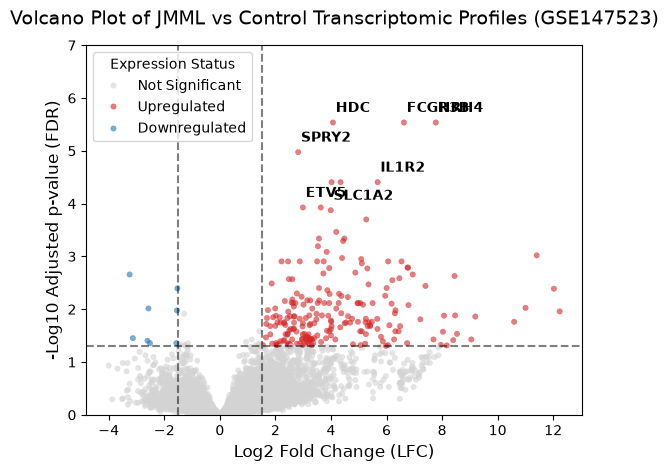

In [15]:
palette = {
    "Not Significant": "lightgrey",
    "Upregulated": "#d62728",
    "Downregulated": "#1f77b4",
}
sns.scatterplot(
    data=res_df,
    x="log2FoldChange",
    y="minus_log10_padj",
    hue="Significance",
    palette=palette,
    alpha=0.6,
    edgecolor=None,
    s=15,
)

# Threshold lines
plt.axhline(-np.log10(padj_threshold), color='black', linestyle='--', alpha=0.5)
plt.axvline(lfc_threshold, color='black', linestyle='--', alpha=0.5)
plt.axvline(-lfc_threshold, color='black', linestyle='--', alpha=0.5)

genes_to_label = ["FCGR3B", "HDC", "HRH4", "SPRY2", "IL1R2", "ETV5", "SLC1A2"]
for gene in genes_to_label:
    gene_row = res_df[res_df["Symbol"] == gene]  # Changed deseq_results to res_df
    if not gene_row.empty:
        plt.text(
            x=gene_row["log2FoldChange"].values[0] + 0.1,
            y=gene_row["minus_log10_padj"].values[0] + 0.2,
            s=gene,
            fontweight="bold",
            fontsize=10,
            color="black",
        )
plt.title(
    "Volcano Plot of JMML vs Control Transcriptomic Profiles (GSE147523)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Log2 Fold Change (LFC)", fontsize=12)
plt.ylabel("-Log10 Adjusted p-value (FDR)", fontsize=12)
plt.legend(title="Expression Status", loc="upper left")

plt.ylim(0, 7)
plt.savefig("../Results/figures/GSE147523_volcano_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# Filter for upregulation

upregulated_signature = res_df[res_df["Significance"] == "Upregulated"]
upregulated_signature = upregulated_signature.sort_values("padj", ascending=True)
upregulated_gene_symbols = upregulated_signature["Symbol"].dropna().unique()
upregulated_signature.to_csv("../Results/signatures/GSE147523_upregulated_signature_full.csv")

with open("../Results/signatures/GSE147523_gene_symbols_only.txt", "w") as f:
    for symbol in upregulated_gene_symbols:
        f.write(f"{symbol}\n")

In [17]:
# Enrichment Analysis for RAS/MAPK pathways

enrichment_results = gp.enrichr(
    gene_list=list(upregulated_gene_symbols),
    gene_sets=["KEGG_2021_Human"],  # The pathway database
    organism="human",
    outdir=None,  # Keep it in memory for now
)

In [18]:
# Top 10 pathways

pathway_df = enrichment_results.results
pathway_df = pathway_df.sort_values("Adjusted P-value", ascending=True)
pathway_df.to_csv("../Results/signatures/GSE147523_pathway_enrichment.csv")

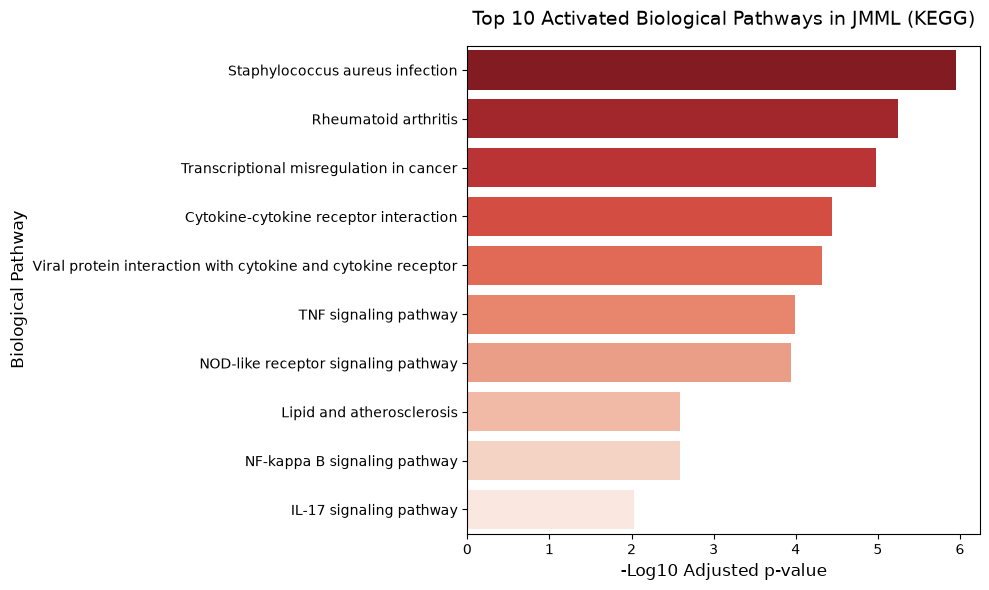

In [19]:
plt.figure(figsize=(10, 6))
pathway_df["minus_log10_padj"] = -np.log10(pathway_df["Adjusted P-value"])

sns.barplot(
    data=pathway_df.head(10),
    x="minus_log10_padj",
    y="Term",
    palette="Reds_r",
    hue="Term",
    legend=False,
)
plt.title(
    "Top 10 Activated Biological Pathways in JMML (KEGG)",
    fontsize=14,
    pad=15,
)
plt.xlabel("-Log10 Adjusted p-value", fontsize=12)
plt.ylabel("Biological Pathway", fontsize=12)

plt.tight_layout()
plt.savefig(
    "../Results/figures/GSE147523_pathway_bar_plot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()